# Separatrix-Following: Interactive Single-Run Notebook

Run one trial at a time. You choose:
- **Field:** `double_vortex` or `double_saddle`
- **Starting centroid:** `initial_pos = (x, y)`
- **Logic:** `'A'` (flow-aligned), `'B'` (most-negative eigenvalue), or `'C'` (blended)

The simulation cell is at the bottom. Change the parameters in that cell and re-run it. Everything above is infrastructure — run those cells once when the kernel starts and then leave them alone.

Analytical overlays (the x=0 line for the vortex field, stable/unstable manifolds for the saddle field) are drawn automatically on the result plot for visual comparison.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy import linalg
from scipy.integrate import solve_ivp
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')


## Vector field

In [2]:
class VectorField:
    """Two field types: 'double_vortex' and 'double_saddle'. Exact equations from Chris's notebooks."""

    def __init__(self, field_type='double_vortex'):
        self.field_type = field_type
        self.vortex1_pos = np.array([-2, -1])
        self.vortex2_pos = np.array([2, -1])
        self.saddle1_pos = np.array([3, 3])
        self.saddle2_pos = np.array([-3, -3])

    def evaluate(self, x, y):
        if self.field_type == 'double_vortex':
            x1, y1 = self.vortex1_pos
            vx1 = -(y - y1); vy1 = (x - x1)
            x2, y2 = self.vortex2_pos
            vx2 =  (y - y2); vy2 = -(x - x2)
            d1 = np.sqrt((x - x1)**2 + (y - y1)**2)
            d2 = np.sqrt((x - x2)**2 + (y - y2)**2)
            w1 = 1.0 / (d1**2 + 0.1)
            w2 = 1.0 / (d2**2 + 0.1)
            vx = (vx1 * w1 + vx2 * w2) / (w1 + w2)
            vy = (vy1 * w1 + vy2 * w2) / (w1 + w2)
            return np.array([10*vx, 10*vy])

        elif self.field_type == 'double_saddle':
            s1 = self.saddle1_pos; s2 = self.saddle2_pos
            rot1, rot2 = np.pi/4, -np.pi/4

            # Saddle 1
            x1c = x - s1[0]; y1c = y - s1[1]
            c1, si1 = np.cos(rot1), np.sin(rot1)
            x1r = c1*x1c - si1*y1c; y1r = si1*x1c + c1*y1c
            u1r =  x1r; v1r = -y1r
            u1 =  c1*u1r + si1*v1r
            v1 = -si1*u1r +  c1*v1r

            # Saddle 2
            x2c = x - s2[0]; y2c = y - s2[1]
            c2, si2 = np.cos(rot2), np.sin(rot2)
            x2r = c2*x2c - si2*y2c; y2r = si2*x2c + c2*y2c
            u2r =  x2r; v2r = -y2r
            u2 =  c2*u2r + si2*v2r
            v2 = -si2*u2r +  c2*v2r

            d1 = np.sqrt((x - s1[0])**2 + (y - s1[1])**2) + 0.01
            d2 = np.sqrt((x - s2[0])**2 + (y - s2[1])**2) + 0.01
            w1 = 1.0 / (d1**2); w2 = 1.0 / (d2**2)
            tw = w1 + w2
            return np.array([(u1*w1 + u2*w2)/tw, (v1*w1 + v2*w2)/tw])

        else:
            raise ValueError(f"Unknown field_type: {self.field_type}")

    def jacobian_twosided(self, x, y, h=0.01):
        fxp, fyp = self.evaluate(x + h, y)
        fxm, fym = self.evaluate(x - h, y)
        fxyp, fyyp = self.evaluate(x, y + h)
        fxym, fyym = self.evaluate(x, y - h)
        return np.array([
            [(fxp - fxm)/(2*h), (fxyp - fxym)/(2*h)],
            [(fyp - fym)/(2*h), (fyyp - fyym)/(2*h)],
        ])


## Four-robot cluster

In [3]:
class RobotCluster4:
    """Four robots in a square, with 4-choose-3 gradient estimation of det(J)."""

    def __init__(self, formation_radius=0.3, initial_pos=(0.0, 0.0),
                 init_mode=2, manual_offset=0.0, seed=None):
        rng = np.random.default_rng(seed)
        self.formation_radius = formation_radius
        self.init_mode = init_mode
        self.centroid = np.array(initial_pos, dtype=float)
        self.positions = np.zeros((4, 2))
        self.vector_readings = np.zeros((4, 2))

        if init_mode == 1:
            self.formation_angle = manual_offset + np.pi/4
            self.rotation_enabled = False
        else:
            self.formation_angle = rng.uniform(0, 2*np.pi)
            self.rotation_enabled = True

        self.angle_history = [self.formation_angle]
        self._update_robot_positions()

    def _update_robot_positions(self):
        angles = np.linspace(0, 2*np.pi, 4, endpoint=False) + self.formation_angle
        for i in range(4):
            self.positions[i] = self.centroid + self.formation_radius * np.array(
                [np.cos(angles[i]), np.sin(angles[i])]
            )

    def update_readings(self, vector_field):
        for i in range(4):
            x, y = self.positions[i]
            self.vector_readings[i] = vector_field.evaluate(x, y)

    def compute_jacobian(self):
        A = np.column_stack([self.positions[:, 0], self.positions[:, 1], np.ones(4)])
        b_u = self.vector_readings[:, 0]; b_v = self.vector_readings[:, 1]
        try:
            cu, *_ = np.linalg.lstsq(A, b_u, rcond=None)
            cv, *_ = np.linalg.lstsq(A, b_v, rcond=None)
            return np.array([[cu[0], cu[1]], [cv[0], cv[1]]])
        except np.linalg.LinAlgError:
            return None

    def compute_determinant_gradient(self):
        """Plane-fit ∇det(J) from four 3-robot sub-formations."""
        J_current = self.compute_jacobian()
        if J_current is None:
            return np.array([0.0, 0.0])
        det_current = np.linalg.det(J_current)

        dets, cents = [], []
        for combo in combinations(range(4), 3):
            pos_s = self.positions[list(combo)]
            read_s = self.vector_readings[list(combo)]
            centroid = np.mean(pos_s, axis=0)
            A = np.column_stack([pos_s[:, 0], pos_s[:, 1], np.ones(3)])
            try:
                cu, _, _, s_u = np.linalg.lstsq(A, read_s[:, 0], rcond=None)
                cv, _, _, _   = np.linalg.lstsq(A, read_s[:, 1], rcond=None)
                if len(s_u) > 0 and s_u[-1] > 1e-12:
                    cond = s_u[0] / s_u[-1]
                    if cond > 1e8:
                        continue
                J = np.array([[cu[0], cu[1]], [cv[0], cv[1]]])
                dets.append(np.linalg.det(J)); cents.append(centroid)
            except np.linalg.LinAlgError:
                continue

        if len(cents) < 4:
            return np.array([0.0, 0.0])
        cents = np.array(cents); dets = np.array(dets)
        Ag = np.column_stack([cents[:, 0], cents[:, 1], np.ones(len(cents))])
        try:
            c, *_ = np.linalg.lstsq(Ag, dets, rcond=None)
            grad = np.array([c[0], c[1]])
            if np.linalg.norm(grad) > 1e-10:
                return -np.sign(det_current) * grad / np.linalg.norm(grad)
            return np.array([0.0, 0.0])
        except np.linalg.LinAlgError:
            return np.array([0.0, 0.0])

    def update_formation_orientation(self, target_direction, adaptation_rate=0.15):
        if not self.rotation_enabled:
            return
        tracking_angle = self.formation_angle - np.pi/4
        target_angle = np.arctan2(target_direction[1], target_direction[0])
        diff = target_angle - tracking_angle
        while diff >  np.pi: diff -= 2*np.pi
        while diff < -np.pi: diff += 2*np.pi
        self.formation_angle = (self.formation_angle + adaptation_rate * diff) % (2*np.pi)
        self.angle_history.append(self.formation_angle)
        self._update_robot_positions()

    def update_positions(self, delta):
        self.centroid = self.centroid + delta
        self._update_robot_positions()


## Three control logics

Each function returns a unit-norm primary direction. Flipping against the flow is handled identically in all three.

- **A — Flow-aligned.** Pick the eigenvector most aligned with the local flow.
- **B — Most-negative eigenvalue.** Pick the eigenvector with the most negative real eigenvalue.
- **C — Sigmoid blend.** Interpolate between A and B based on det(J).

In [4]:
def _normalise(v):
    n = np.linalg.norm(v)
    return v / n if n > 1e-12 else v

def _consistent_with_flow(direction, flow_norm):
    return direction if np.dot(direction, flow_norm) >= 0 else -direction


def logic_A_flow_aligned(J, flow):
    flow_n = _normalise(flow)
    evals, evecs = np.linalg.eig(J)
    e1 = _normalise(np.real(evecs[:, 0]))
    e2 = _normalise(np.real(evecs[:, 1]))
    primary = e1 if abs(np.dot(flow_n, e1)) > abs(np.dot(flow_n, e2)) else e2
    return _consistent_with_flow(primary, flow_n)


def logic_B_most_negative(J, flow):
    flow_n = _normalise(flow)
    evals, evecs = np.linalg.eig(J)
    e1 = _normalise(np.real(evecs[:, 0]))
    e2 = _normalise(np.real(evecs[:, 1]))
    primary = e1 if np.real(evals[0]) < np.real(evals[1]) else e2
    return _consistent_with_flow(primary, flow_n)


def logic_C_blended(J, flow, det_J, blend_center=5.0, blend_steepness=2.0):
    flow_n = _normalise(flow)
    evals, evecs = np.linalg.eig(J)
    e1 = _normalise(np.real(evecs[:, 0]))
    e2 = _normalise(np.real(evecs[:, 1]))

    w = 0.5 * (1 + np.tanh((det_J - blend_center) / blend_steepness))

    eigval_score1 = np.exp(-max(0, np.real(evals[0])))
    eigval_score2 = np.exp(-max(0, np.real(evals[1])))
    flow_score1   = abs(np.dot(flow_n, e1))
    flow_score2   = abs(np.dot(flow_n, e2))

    s1 = (1 - w) * eigval_score1 + w * flow_score1
    s2 = (1 - w) * eigval_score2 + w * flow_score2

    primary = e1 if s1 > s2 else e2
    return _consistent_with_flow(primary, flow_n)


## Simulation driver

In [5]:
def simulate(field_type, logic, initial_pos,
             n_steps=300, step_size=0.02,
             rotation_rate=0.15, correction_weight=0.5,
             formation_radius=0.3, init_mode=2, manual_offset=0.0,
             seed=None):
    """One trial. Returns (centroid_history, eigvec_history, robots, vector_field)."""
    vf = VectorField(field_type=field_type)
    robots = RobotCluster4(formation_radius=formation_radius,
                           initial_pos=initial_pos,
                           init_mode=init_mode,
                           manual_offset=manual_offset,
                           seed=seed)

    centroid_hist = np.zeros((n_steps, 2))
    eigvec_hist = []

    for step in range(n_steps):
        centroid_hist[step] = robots.centroid
        robots.update_readings(vf)

        correction = robots.compute_determinant_gradient()
        J = robots.compute_jacobian()
        if J is None:
            continue

        det_J = np.linalg.det(J)
        flow = np.mean(robots.vector_readings, axis=0)

        if logic == 'A':
            primary = logic_A_flow_aligned(J, flow)
        elif logic == 'B':
            primary = logic_B_most_negative(J, flow)
        elif logic == 'C':
            primary = logic_C_blended(J, flow, det_J)
        else:
            raise ValueError(f"Unknown logic: {logic}")

        robots.update_formation_orientation(primary, rotation_rate)

        corr_parallel = np.dot(correction, primary) * primary
        corr_orthog   = correction - corr_parallel
        direction = primary + correction_weight * corr_orthog
        direction = _normalise(direction)

        robots.update_positions(step_size * direction)
        eigvec_hist.append((robots.centroid.copy(), primary.copy()))

    return centroid_hist, eigvec_hist, robots, vf


## Analytical overlays

Used by the plotting function so you can visually judge how close the cluster got to the true structure.
- `double_vortex`: the dividing streamline is exactly `x = 0` (symmetry argument).
- `double_saddle`: integrate stable and unstable manifolds from each saddle's eigenvectors.

In [6]:
def compute_saddle_manifolds(vf, t_max=20.0, offset=0.01, rtol=1e-8, max_step=0.005):
    def flow(t, s): return vf.evaluate(s[0], s[1])
    def flow_back(t, s): return -vf.evaluate(s[0], s[1])

    manifolds = {'stable': [], 'unstable': []}
    for saddle in [vf.saddle1_pos, vf.saddle2_pos]:
        J = vf.jacobian_twosided(saddle[0], saddle[1])
        evals, evecs = np.linalg.eig(J)
        for k in range(2):
            v = _normalise(np.real(evecs[:, k]))
            for sign in (+1, -1):
                start = saddle + sign * offset * v
                if np.real(evals[k]) > 0:
                    sol = solve_ivp(flow, [0, t_max], start, rtol=rtol, max_step=max_step)
                    manifolds['unstable'].append(sol.y)
                else:
                    sol = solve_ivp(flow_back, [0, t_max], start, rtol=rtol, max_step=max_step)
                    manifolds['stable'].append(sol.y)
    return manifolds


## Result plot

In [7]:
def plot_trial(centroid_hist, eigvec_hist, robots, vf, title=''):
    fig, ax = plt.subplots(figsize=(9, 9))

    if vf.field_type == 'double_vortex':
        xlim, ylim = (-5, 5), (-5, 5)
    else:
        xlim, ylim = (-6, 6), (-6, 6)

    # Background quiver
    xg = np.linspace(xlim[0], xlim[1], 22)
    yg = np.linspace(ylim[0], ylim[1], 22)
    X, Y = np.meshgrid(xg, yg)
    U = np.zeros_like(X); V = np.zeros_like(Y)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            U[i, j], V[i, j] = vf.evaluate(X[i, j], Y[i, j])
    mag = np.sqrt(U**2 + V**2) + 1e-6
    ax.quiver(X, Y, U/mag, V/mag, alpha=0.25, color='gray')

    # Analytical overlay
    if vf.field_type == 'double_vortex':
        ax.axvline(0, color='red', linestyle='--', linewidth=2,
                   label='Analytical dividing streamline (x=0)')
        ax.scatter(*vf.vortex1_pos, c='black', s=80, zorder=5)
        ax.scatter(*vf.vortex2_pos, c='black', s=80, zorder=5)
    else:
        mf = compute_saddle_manifolds(vf)
        for k, curve in enumerate(mf['unstable']):
            ax.plot(curve[0], curve[1], 'b-', lw=2, alpha=0.8,
                    label='Unstable manifold' if k == 0 else None)
        for k, curve in enumerate(mf['stable']):
            ax.plot(curve[0], curve[1], 'g-', lw=2, alpha=0.8,
                    label='Stable manifold' if k == 0 else None)
        ax.scatter(*vf.saddle1_pos, c='red', s=120, marker='o', zorder=5, label='Saddle')
        ax.scatter(*vf.saddle2_pos, c='red', s=120, marker='o', zorder=5)

    # Trajectory
    ax.plot(centroid_hist[:, 0], centroid_hist[:, 1], 'b-', alpha=0.8,
            lw=1.5, label='Cluster path')
    ax.scatter(centroid_hist[0, 0], centroid_hist[0, 1],
               c='green', s=120, zorder=6, label='Start')
    ax.scatter(centroid_hist[-1, 0], centroid_hist[-1, 1],
               c='red', s=120, zorder=6, label='End')

    # Primary direction samples along the path
    for pos, ev in eigvec_hist[::20]:
        ax.arrow(pos[0], pos[1], ev[0]*0.25, ev[1]*0.25,
                 head_width=0.08, head_length=0.12,
                 fc='orange', ec='orange', alpha=0.6)

    # Final robot positions
    for i, pos in enumerate(robots.positions):
        ax.scatter(*pos, c='blue', s=60, zorder=7)
        ax.text(pos[0]+0.08, pos[1]+0.08, f'R{i+1}', fontsize=9)

    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_aspect('equal'); ax.grid(alpha=0.3)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title(title)
    ax.legend(loc='upper right', fontsize=9)
    plt.tight_layout()
    return fig


---

## Run one trial

Edit the parameters below and re-run this cell. Everything above should already be loaded in the kernel.

**Valid field types:** `'double_vortex'`, `'double_saddle'`
**Valid logics:** `'A'` (flow-aligned), `'B'` (most-negative eigenvalue), `'C'` (blended)

Reasonable starting positions:
- `double_vortex`: anywhere away from the vortex centres at `(-2,-1)` and `(2,-1)`. The dividing streamline is `x = 0`. Try `(-0.5, -3.4)` or `(2.5, 3.0)`.
- `double_saddle`: anywhere between or outside the two saddles at `(3,3)` and `(-3,-3)`. Try `(-2.02, -2.5)` or `(1.5, -1.0)`.


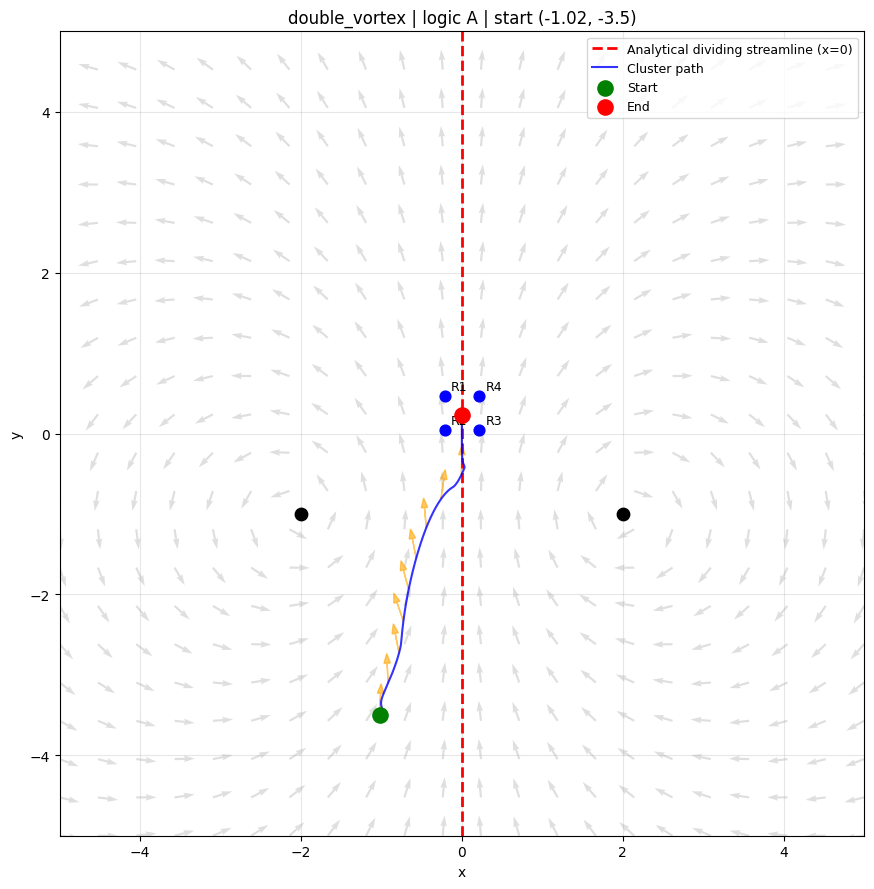

Start:        (-1.020, -3.500)
End:          (+0.000, +0.234)
Path length:  3.980
det(J) end:   +0.0000
trace(J) end: +8.7783


In [22]:
## Double Saddle mode B works really well for heteroclinic. especially converging. Diverging, not so much. Goes beyong critical point
## Double Saddle mode A Does not work

## Double Vortex mode A Works well


# -------- EDIT THESE --------
field_type   = 'double_vortex'     # 'double_vortex' or 'double_saddle'
logic        = 'A'                 # 'A', 'B', or 'C'
initial_pos  = (-1.02, -3.5)       # starting centroid

# Simulation parameters (defaults usually fine)
n_steps           = 200
step_size         = 0.02
rotation_rate     = 0.15
correction_weight = 0.5
formation_radius  = 0.3
init_mode         = 2              # 2 = square with random angle, 1 = square with fixed angle
seed              = 42             # for reproducible formation angle; set to None for fresh random
# ----------------------------

centroid_hist, eigvec_hist, robots, vf = simulate(
    field_type=field_type,
    logic=logic,
    initial_pos=initial_pos,
    n_steps=n_steps,
    step_size=step_size,
    rotation_rate=rotation_rate,
    correction_weight=correction_weight,
    formation_radius=formation_radius,
    init_mode=init_mode,
    seed=seed,
)

title = f"{field_type} | logic {logic} | start {initial_pos}"
_ = plot_trial(centroid_hist, eigvec_hist, robots, vf, title=title)
plt.show()

# Quick numerical summary
start = centroid_hist[0]; end = centroid_hist[-1]
path_length = np.sum(np.linalg.norm(np.diff(centroid_hist, axis=0), axis=1))
J_end = vf.jacobian_twosided(*end)
print(f"Start:        ({start[0]:+.3f}, {start[1]:+.3f})")
print(f"End:          ({end[0]:+.3f}, {end[1]:+.3f})")
print(f"Path length:  {path_length:.3f}")
print(f"det(J) end:   {np.linalg.det(J_end):+.4f}")
print(f"trace(J) end: {np.trace(J_end):+.4f}")


---

### Optional: det(J) heatmap for the current field

Useful when picking starting positions — shows where det(J) is near zero.

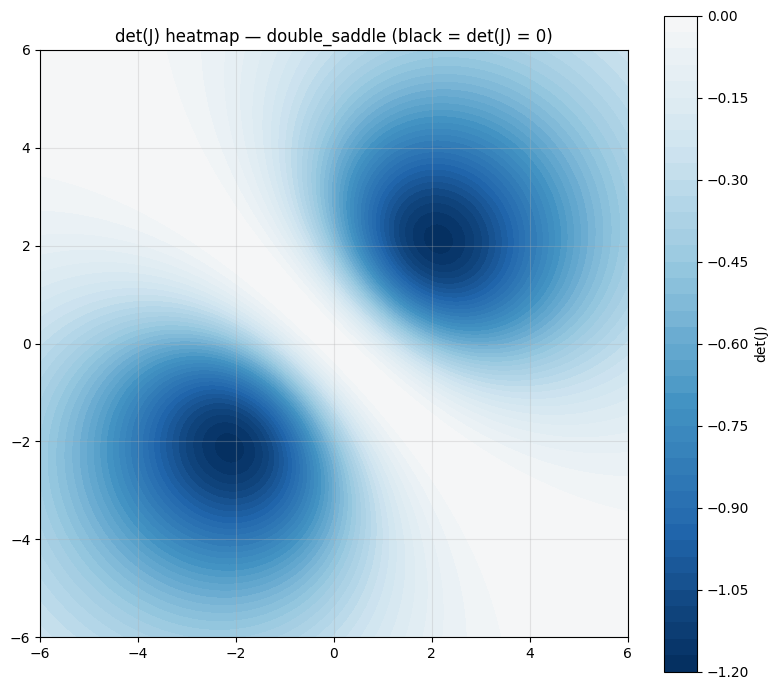

In [9]:
def plot_det_heatmap(field_type='double_vortex', resolution=100):
    vf = VectorField(field_type=field_type)
    if field_type == 'double_vortex':
        xlim, ylim = (-5, 5), (-5, 5)
    else:
        xlim, ylim = (-6, 6), (-6, 6)

    xs = np.linspace(*xlim, resolution)
    ys = np.linspace(*ylim, resolution)
    X, Y = np.meshgrid(xs, ys)
    D = np.zeros_like(X)
    for i in range(resolution):
        for j in range(resolution):
            D[i, j] = np.linalg.det(vf.jacobian_twosided(X[i, j], Y[i, j]))

    lim = max(abs(D.min()), abs(D.max()))
    fig, ax = plt.subplots(figsize=(8, 7))
    cs = ax.contourf(X, Y, D, levels=40, cmap='RdBu_r', vmin=-lim, vmax=lim)
    ax.contour(X, Y, D, levels=[0], colors='black', linewidths=2)
    plt.colorbar(cs, ax=ax, label='det(J)')
    ax.set_aspect('equal'); ax.grid(alpha=0.3)
    ax.set_title(f'det(J) heatmap — {field_type} (black = det(J) = 0)')
    plt.tight_layout()
    return fig

_ = plot_det_heatmap(field_type='double_saddle')
plt.show()
